# Hybrid Brain Tumor MRI Detection + Segmentation — Version 2

## Computer Vision + Classical ML + Deep Learning + U-Net + Hybrid Fusion

This notebook builds directly on the original `Hybrid_Brain_Tumor_MRI_Detection(1).ipynb`.

### Version 2 upgrades
- Excludes segmentation masks from the classification image pool.
- Supports patient/case-level splitting when group IDs can be inferred or supplied.
- Audits duplicates and possible leakage.
- Expands handcrafted features to **HOG + LBP + GLCM + intensity + entropy + edge statistics**.
- Tunes the classical SVM instead of fixing its hyperparameters.
- Uses **EfficientNetV2B0** transfer learning and deep embeddings.
- Compares **early fusion, late fusion, and stacking**.
- Adds optional **U-Net tumor segmentation** when image/mask pairs exist.
- Reports sensitivity, specificity, precision, NPV, F1, balanced accuracy, ROC-AUC and PR-AUC.
- Adds bootstrap confidence intervals and clinically useful threshold strategies.
- Adds error analysis, model export, and single-MRI inference.

> Research/educational pipeline only; it is not a clinically validated diagnostic system.

## 0. Install dependencies

Run once if needed. Restart the Jupyter kernel if requested after TensorFlow/OpenCV installation.

In [1]:
%pip install -q numpy pandas matplotlib scikit-learn scikit-image opencv-python tensorflow joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import os, re, random, warnings, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import joblib

from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
from skimage.measure import shannon_entropy

from sklearn.model_selection import (
    train_test_split, GroupShuffleSplit, StratifiedGroupKFold,
    StratifiedKFold, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, jaccard_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)

TensorFlow: 2.13.1
OpenCV: 4.11.0


## 1. Configuration

Change `DATASET_DIR` to your local dataset. The defaults preserve the original experiment:
`Normal` versus `Embryonic Tumors`.

In [3]:
DATASET_DIR = Path(r"..\Datasets\Brain Tumor 12K Mri Images\Images_\Images_")
MODEL_DIR = Path("models_v2")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

NEGATIVE_CLASS = "Normal"
POSITIVE_CLASS = "Embryonic Tumors"

IMG_SIZE = 224
SEG_SIZE = 256
BATCH_SIZE = 16
SEG_BATCH_SIZE = 8
VAL_SIZE = 0.15
TEST_SIZE = 0.15

SUPPORTED_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
MASK_TOKENS = ("mask", "segmentation", "_seg", "label", "consensus")

print("Dataset:", DATASET_DIR.resolve())
print("Exists:", DATASET_DIR.exists())

Dataset: C:\Users\fgmam\Documents\GitHub\Medical-Imaging-Research\Datasets\Brain Tumor 12K Mri Images\Images_\Images_
Exists: True


## 2. Dataset discovery, mask exclusion, and leakage audit

`infer_group_id()` is only a filename heuristic. If your dataset supplies an official patient ID, replace this heuristic with the official identifier.

In [4]:
def is_mask_file(path):
    stem = Path(path).stem.lower()
    return any(tok in stem for tok in MASK_TOKENS)

def infer_group_id(path):
    stem = Path(path).stem.lower()
    stem = re.sub(r"(?:_?mask(?:_consensus)?|_?seg(?:mentation)?|_?label)$", "", stem)
    stem = re.sub(r"[_\- ]?(slice|image|img|scan)[_\- ]?\d+$", "", stem)
    stem = re.sub(r"[_\- ]?\d{1,4}$", "", stem)
    return stem.strip("_- ") or Path(path).stem.lower()

def build_classification_dataframe(dataset_dir):
    mapping = {NEGATIVE_CLASS: 0, POSITIVE_CLASS: 1}
    rows = []
    for class_name, label in mapping.items():
        class_dir = dataset_dir / class_name
        if not class_dir.exists():
            print("WARNING: missing:", class_dir)
            continue
        for p in class_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS:
                rows.append({
                    "path": str(p),
                    "class_name": class_name,
                    "label": label,
                    "is_mask": is_mask_file(p),
                    "group_id": infer_group_id(p),
                })
    return pd.DataFrame(rows)

df_all = build_classification_dataframe(DATASET_DIR)
if df_all.empty:
    raise FileNotFoundError("No images found. Check DATASET_DIR and class folder names.")

print("All discovered files:", len(df_all))
display(df_all.groupby(["class_name", "is_mask"]).size().rename("count"))

df = df_all.loc[~df_all.is_mask].copy().reset_index(drop=True)
print("Classification images after mask exclusion:", len(df))
display(df.head())

All discovered files: 6225


class_name        is_mask
Embryonic Tumors  False      1761
                  True        873
Normal            False      2394
                  True       1197
Name: count, dtype: int64

Classification images after mask exclusion: 4155


,path,class_name,label,is_mask,group_id
0,..\Datasets\Brain Tumor 12K Mri Images\Images_...,Normal,0,False,"mri brain - normal (70-year-old) ventricle , b..."
1,..\Datasets\Brain Tumor 12K Mri Images\Images_...,Normal,0,False,"mri brain - normal (70-year-old) ventricle , b..."
2,..\Datasets\Brain Tumor 12K Mri Images\Images_...,Normal,0,False,"mri brain - normal (70-year-old) ventricle , b..."
3,..\Datasets\Brain Tumor 12K Mri Images\Images_...,Normal,0,False,"mri brain - normal (70-year-old) ventricle , b..."
4,..\Datasets\Brain Tumor 12K Mri Images\Images_...,Normal,0,False,"mri brain - normal (70-year-old) ventricle , b..."


In [5]:
def file_md5(path, chunk=1024*1024):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

RUN_HASH_AUDIT = True

if RUN_HASH_AUDIT:
    df["md5"] = [file_md5(p) for p in df.path]
    dup = df[df.duplicated("md5", keep=False)].sort_values("md5")
    print("Duplicate-file rows:", len(dup))
    if len(dup):
        display(dup[["path","class_name","group_id","md5"]].head(30))
else:
    df["md5"] = None

Duplicate-file rows: 1388


,path,class_name,group_id,md5
3761,..\Datasets\Brain Tumor 12K Mri Images\Images_...,Embryonic Tumors,t2 - medulloblastoma,0113de176dca162ba2cacb45cc593dcf
3763,..\Datasets\Brain Tumor 12K Mri Images\Images_...,Embryonic Tumors,t2 - medulloblastoma,0113de176dca162ba2cacb45cc593dcf
3087,..\Datasets\Brain Tumor 12K Mri Images\Images_...,Embryonic Tumors,t1c+ - medulloblastoma posterior cranial fossa...,071da3fcf0d0e62293b8edfcff35203c
3113,..\Datasets\Brain Tumor 12K Mri Images\Images_...,Embryonic Tumors,t1c+ - medulloblastoma posterior cranial fossa...,071da3fcf0d0e62293b8edfcff35203c
3720,..\Datasets\Brain Tumor 12K Mri Images\Images_...,Embryonic Tumors,t2 - medulloblastoma 016_bbox,0a1355da273f6bece6708573acff312a
3146,..\Datasets\Brain Tumor 12K Mri Images\Images_...,Embryonic Tumors,"t1c+ - medulloblastoma posterior fossa , paraf...",0a1355da273f6bece6708573acff312a
2964,..\Datasets\Brain Tumor 12K Mri Images\Images_...,Embryonic Tumors,t1c+ - medulloblastoma,12a380cfd0f29d36ad99b55eecdf92f7
3543,..\Datasets\Brain Tumor 12K Mri Images\Images_...,Embryonic Tumors,"t1c+ - medulloblastoma ventricle , supratentorial",12a380cfd0f29d36ad99b55eecdf92f7
3651,..\Datasets\Brain Tumor 12K Mri Images\Images_...,Embryonic Tumors,t2 - medulloblastoma - desmoplasticnodular pineal,1ac73b68ca602a3636904dd47763340e
3649,..\Datasets\Brain Tumor 12K Mri Images\Images_...,Embryonic Tumors,t2 - medulloblastoma - desmoplasticnodular pineal,1ac73b68ca602a3636904dd47763340e


## 3. Leakage-safe train / validation / test split

When repeated case IDs are detected, groups are kept isolated across partitions. Otherwise the notebook falls back to a stratified image-level split and warns you.

In [6]:
def grouped_split(data, val_size=0.15, test_size=0.15, seed=42):
    data = data.copy().reset_index(drop=True)
    use_groups = data.group_id.nunique() < len(data) * 0.98

    if use_groups:
        print("Using GROUPED splitting.")
        g1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        trainval_idx, test_idx = next(g1.split(data, data.label, groups=data.group_id))
        trainval = data.iloc[trainval_idx].reset_index(drop=True)
        test = data.iloc[test_idx].reset_index(drop=True)

        relative_val = val_size / (1.0 - test_size)
        g2 = GroupShuffleSplit(n_splits=1, test_size=relative_val, random_state=seed+1)
        train_idx, val_idx = next(g2.split(trainval, trainval.label, groups=trainval.group_id))
        train = trainval.iloc[train_idx].reset_index(drop=True)
        val = trainval.iloc[val_idx].reset_index(drop=True)
    else:
        print("WARNING: falling back to stratified IMAGE-level splitting.")
        trainval, test = train_test_split(
            data, test_size=test_size, stratify=data.label, random_state=seed
        )
        relative_val = val_size / (1.0 - test_size)
        train, val = train_test_split(
            trainval, test_size=relative_val, stratify=trainval.label, random_state=seed+1
        )
        train, val, test = [x.reset_index(drop=True) for x in (train, val, test)]
    return train, val, test

train_df, val_df, test_df = grouped_split(df, VAL_SIZE, TEST_SIZE, SEED)

for name, part in [("train",train_df),("val",val_df),("test",test_df)]:
    print(name, "n=", len(part), "groups=", part.group_id.nunique(),
          "positive fraction=", round(part.label.mean(), 3))

for an,a,bn,b in [
    ("train",train_df,"val",val_df),
    ("train",train_df,"test",test_df),
    ("val",val_df,"test",test_df)
]:
    print(an, bn, "group overlap =", len(set(a.group_id) & set(b.group_id)))

Using GROUPED splitting.
train n= 3015 groups= 1498 positive fraction= 0.387
val n= 547 groups= 321 positive fraction= 0.481
test n= 593 groups= 321 positive fraction= 0.556
train val group overlap = 0
train test group overlap = 0
val test group overlap = 0


## 4. MRI preprocessing

The classical-CV branch uses normalized grayscale MRI. The deep branch converts the same preprocessed anatomy to a 0–255 three-channel representation for the pretrained backbone.

In [7]:
def read_image_safe(path, grayscale=True):
    flag = cv2.IMREAD_GRAYSCALE if grayscale else cv2.IMREAD_COLOR
    img = cv2.imread(str(path), flag)
    if img is None:
        arr = np.fromfile(str(path), dtype=np.uint8)
        img = cv2.imdecode(arr, flag)
    if img is None:
        raise ValueError(f"Could not read image: {path}")
    return img

def crop_nonzero_brain(img, threshold=5):
    pts = np.argwhere(img > threshold)
    if len(pts) == 0:
        return img
    y0,x0 = pts.min(axis=0)
    y1,x1 = pts.max(axis=0) + 1
    return img[y0:y1, x0:x1]

def preprocess_cv(path, size=IMG_SIZE):
    img = read_image_safe(path, True)
    img = crop_nonzero_brain(img)
    img = cv2.GaussianBlur(img, (3,3), 0)
    img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(img)
    img = cv2.resize(img, (size,size), interpolation=cv2.INTER_AREA)
    return img.astype(np.float32) / 255.0

def preprocess_dl_numpy(path, size=IMG_SIZE):
    gray = preprocess_cv(path, size)
    return (np.stack([gray,gray,gray], axis=-1) * 255.0).astype(np.float32)

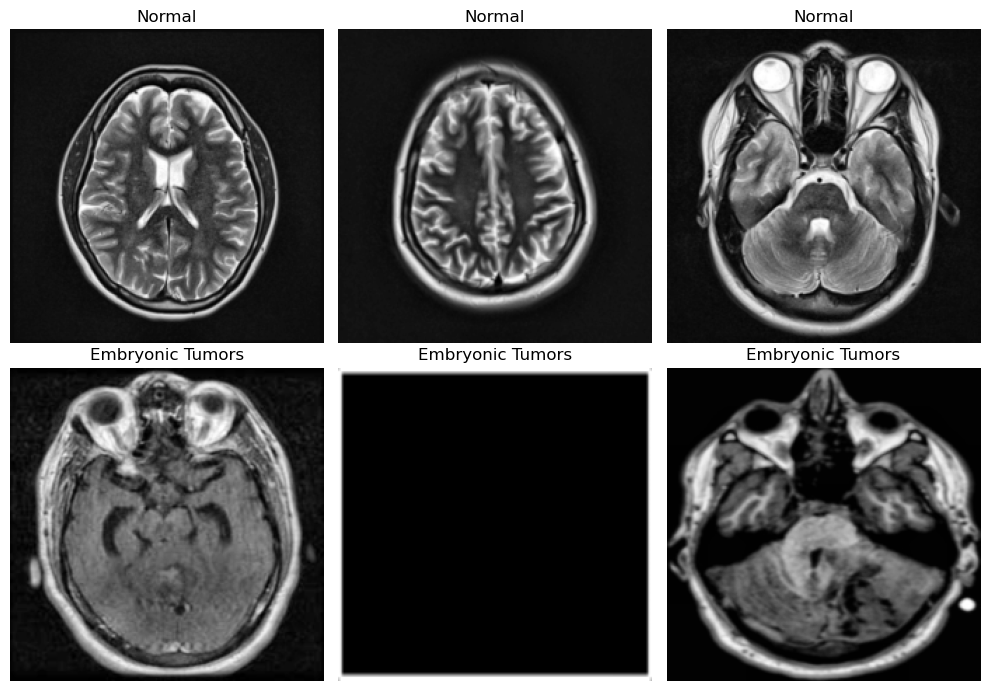

In [8]:
sample = pd.concat([
    train_df[train_df.label==0].sample(min(3,(train_df.label==0).sum()), random_state=SEED),
    train_df[train_df.label==1].sample(min(3,(train_df.label==1).sum()), random_state=SEED)
])
fig, axes = plt.subplots(2,3,figsize=(10,7))
for ax,(_,row) in zip(axes.ravel(), sample.iterrows()):
    ax.imshow(preprocess_cv(row.path), cmap="gray")
    ax.set_title(row.class_name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Rich handcrafted feature branch

Features: HOG, uniform LBP, multi-angle GLCM texture, intensity percentiles/statistics, Shannon entropy, and Canny edge density.

In [9]:
LBP_POINTS = 24
LBP_RADIUS = 3

def handcrafted_features(path):
    x = preprocess_cv(path)
    u8 = np.clip(x*255,0,255).astype(np.uint8)

    h = hog(x, orientations=9, pixels_per_cell=(16,16),
            cells_per_block=(2,2), block_norm="L2-Hys", feature_vector=True)

    lbp = local_binary_pattern(u8, LBP_POINTS, LBP_RADIUS, method="uniform")
    lh,_ = np.histogram(lbp.ravel(), bins=np.arange(0,LBP_POINTS+3),
                        range=(0,LBP_POINTS+2), density=True)

    q = (u8//32).astype(np.uint8)
    g = graycomatrix(q, distances=[1,2],
                     angles=[0,np.pi/4,np.pi/2,3*np.pi/4],
                     levels=8, symmetric=True, normed=True)
    gf = []
    for prop in ["contrast","dissimilarity","homogeneity","energy","correlation","ASM"]:
        gf.extend(graycoprops(g, prop).ravel())

    v = x.ravel()
    intensity = [
        v.mean(), v.std(), np.median(v),
        np.percentile(v,10), np.percentile(v,25),
        np.percentile(v,75), np.percentile(v,90),
        v.min(), v.max(), shannon_entropy(u8)
    ]

    edges = cv2.Canny(u8,50,150)
    edge = [(edges>0).mean(), edges.mean()/255.0]

    return np.concatenate([h, lh, gf, intensity, edge]).astype(np.float32)

def feature_matrix(frame):
    out=[]
    for i,p in enumerate(frame.path):
        out.append(handcrafted_features(p))
        if (i+1)%250==0:
            print(i+1, "/", len(frame))
    return np.vstack(out)

Xh_train = feature_matrix(train_df)
Xh_val = feature_matrix(val_df)
Xh_test = feature_matrix(test_df)

y_train = train_df.label.to_numpy()
y_val = val_df.label.to_numpy()
y_test = test_df.label.to_numpy()

print(Xh_train.shape)

250 / 3015
500 / 3015
750 / 3015
1000 / 3015
1250 / 3015
1500 / 3015
1750 / 3015
2000 / 3015
2250 / 3015
2500 / 3015
2750 / 3015
3000 / 3015
250 / 547
500 / 547
250 / 593
500 / 593
(3015, 6170)


## 6. Tuned classical ML baseline

In [10]:
grouped_cv = train_df.group_id.nunique() < len(train_df)*0.98
if grouped_cv:
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_groups = train_df.group_id.to_numpy()
else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_groups = None

svm_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA(random_state=SEED)),
    ("svm", SVC(kernel="rbf", class_weight="balanced",
                probability=True, random_state=SEED))
])

params = {
    "pca__n_components":[0.90,0.95,0.99],
    "svm__C":[0.5,1,2,5,10,20],
    "svm__gamma":["scale","auto",1e-4,1e-3,1e-2]
}

search = RandomizedSearchCV(
    svm_pipe, params, n_iter=15, scoring="roc_auc",
    cv=cv, n_jobs=-1, random_state=SEED, verbose=1
)
search.fit(Xh_train, y_train, groups=cv_groups)
svm_baseline = search.best_estimator_
print("Best CV AUC:", search.best_score_)
print("Best params:", search.best_params_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best CV AUC: 0.9895168022247995
Best params: {'svm__gamma': 'scale', 'svm__C': 2, 'pca__n_components': 0.99}


## 7. EfficientNetV2B0 deep-learning classifier

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

def tf_load_image(path,label):
    def _py(p):
        return preprocess_dl_numpy(p.numpy().decode("utf-8"))
    x = tf.py_function(_py,[path],Tout=tf.float32)
    x.set_shape((IMG_SIZE,IMG_SIZE,3))
    return x, tf.cast(label,tf.float32)

def make_ds(frame, training=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices(
        (frame.path.astype(str).to_numpy(), frame.label.to_numpy())
    )
    if training:
        ds = ds.shuffle(len(frame),seed=SEED,reshuffle_each_iteration=True)
    return ds.map(tf_load_image,num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)

train_ds=make_ds(train_df,True)
val_ds=make_ds(val_df)
test_ds=make_ds(test_df)

augmentation=keras.Sequential([
    layers.RandomRotation(0.04),
    layers.RandomTranslation(0.04,0.04),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.10)
],name="mri_augmentation")

inp=keras.Input((IMG_SIZE,IMG_SIZE,3),name="mri")
x=augmentation(inp)
backbone=keras.applications.EfficientNetV2B0(
    include_top=False,weights="imagenet",input_tensor=x,
    pooling="avg",include_preprocessing=True
)
backbone.trainable=False
x=layers.Dropout(0.30)(backbone.output)
emb=layers.Dense(256,activation="relu",name="deep_embedding")(x)
x=layers.Dropout(0.25)(emb)
out=layers.Dense(1,activation="sigmoid",name="tumor_probability")(x)
dl_model=keras.Model(inp,out)

dl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc"),
        keras.metrics.AUC(curve="PR",name="pr_auc"),
        keras.metrics.Recall(name="sensitivity")
    ]
)
dl_model.summary()

24274472/24274472 [==============================] - 0s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 mri (InputLayer)            [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 mri_augmentation (Sequenti  (None, 224, 224, 3)          0         ['mri[0][0]']                 
 al)                                                                                              
                                                                                                  
 rescaling (Rescaling)       (None, 224, 224, 3)          0         ['mri_augmentation[0][0]']    
                                                                                                  
 normalization (Normalizati  

In [14]:
# ============================================================
# CLASS WEIGHTS + CALLBACKS + INITIAL TRAINING
# Keras-version-compatible checkpointing
# ============================================================

# ------------------------------------------------------------
# 1. Calculate balanced class weights
# ------------------------------------------------------------

classes = np.unique(y_train)

cw = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {
    int(c): float(w)
    for c, w in zip(classes, cw)
}

print("Classes:", classes)
print("Class weights:", class_weight)


# ------------------------------------------------------------
# 2. Define checkpoint path
# ------------------------------------------------------------

# Save WEIGHTS ONLY instead of the complete .keras model.
#
# This avoids the native Keras-format compatibility problem:
#
# ValueError:
# The following argument(s) are not supported with the
# native Keras format: ['options']
#
# The .h5 extension is appropriate here because we are
# checkpointing model weights only.

checkpoint_path = str(
    MODEL_DIR / "best_classifier_weights.h5"
)

print("Checkpoint path:", checkpoint_path)


# ------------------------------------------------------------
# 3. Training callbacks
# ------------------------------------------------------------

callbacks = [

    # Stop training if validation AUC does not improve
    # for 6 consecutive epochs.
    #
    # restore_best_weights=True means the model in memory
    # will automatically return to the best epoch.
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate if validation AUC plateaus.
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    # Save ONLY the weights from the epoch with the
    # highest validation AUC.
    #
    # This avoids the .keras native-model saving issue.
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )
]


# ------------------------------------------------------------
# 4. Train classification head
# ------------------------------------------------------------

history_head = dl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)


# ------------------------------------------------------------
# 5. Explicitly restore the best checkpoint
# ------------------------------------------------------------

# EarlyStopping already restores the best weights when it
# activates, but loading the checkpoint explicitly guarantees
# that we continue with the best validation-AUC weights even
# if all 20 epochs complete without EarlyStopping triggering.

dl_model.load_weights(checkpoint_path)

print()
print("Training stage complete.")
print("Best classifier weights restored from:")
print(checkpoint_path)

Classes: [0 1]
Class weights: {0: 0.8161884136437466, 1: 1.290667808219178}
Checkpoint path: models_v2\best_classifier_weights.h5
Epoch 1/20
189/189 [==============================] - ETA: 0s - loss: 0.1619 - accuracy: 0.9267 - auc: 0.9834 - pr_auc: 0.9752 - sensitivity: 0.9366
Epoch 1: val_auc improved from -inf to 0.99191, saving model to models_v2\best_classifier_weights.h5
189/189 [==============================] - 65s 344ms/step - loss: 0.1619 - accuracy: 0.9267 - auc: 0.9834 - pr_auc: 0.9752 - sensitivity: 0.9366 - val_loss: 0.1533 - val_accuracy: 0.9196 - val_auc: 0.9919 - val_pr_auc: 0.9912 - val_sensitivity: 0.8479 - lr: 0.0010
Epoch 2/20
189/189 [==============================] - ETA: 0s - loss: 0.1338 - accuracy: 0.9390 - auc: 0.9889 - pr_auc: 0.9829 - sensitivity: 0.9469
Epoch 2: val_auc improved from 0.99191 to 0.99367, saving model to models_v2\best_classifier_weights.h5
189/189 [==============================] - 172s 909ms/step - loss: 0.1338 - accuracy: 0.9390 - auc: 0.

## 8. Fine-tune the upper backbone

In [15]:
backbone.trainable=True
cut=int(len(backbone.layers)*0.80)
for layer in backbone.layers[:cut]:
    layer.trainable=False
for layer in backbone.layers:
    if isinstance(layer,layers.BatchNormalization):
        layer.trainable=False

dl_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc"),
        keras.metrics.AUC(curve="PR",name="pr_auc"),
        keras.metrics.Recall(name="sensitivity")
    ]
)

history_fine=dl_model.fit(
    train_ds,validation_data=val_ds,epochs=15,
    class_weight=class_weight,callbacks=callbacks
)

Epoch 1/15
189/189 [==============================] - ETA: 0s - loss: 0.1062 - accuracy: 0.9549 - auc: 0.9929 - pr_auc: 0.9895 - sensitivity: 0.9623
Epoch 1: val_auc improved from 0.99481 to 0.99564, saving model to models_v2\best_classifier_weights.h5
189/189 [==============================] - 80s 378ms/step - loss: 0.1062 - accuracy: 0.9549 - auc: 0.9929 - pr_auc: 0.9895 - sensitivity: 0.9623 - val_loss: 0.1131 - val_accuracy: 0.9433 - val_auc: 0.9956 - val_pr_auc: 0.9953 - val_sensitivity: 0.9087 - lr: 1.0000e-05
Epoch 2/15
189/189 [==============================] - ETA: 0s - loss: 0.0874 - accuracy: 0.9645 - auc: 0.9954 - pr_auc: 0.9928 - sensitivity: 0.9675
Epoch 2: val_auc did not improve from 0.99564
189/189 [==============================] - 72s 383ms/step - loss: 0.0874 - accuracy: 0.9645 - auc: 0.9954 - pr_auc: 0.9928 - sensitivity: 0.9675 - val_loss: 0.0965 - val_accuracy: 0.9634 - val_auc: 0.9953 - val_pr_auc: 0.9949 - val_sensitivity: 0.9544 - lr: 1.0000e-05
Epoch 3/15
189

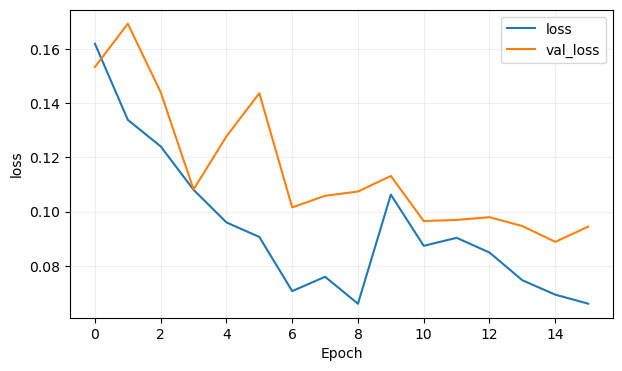

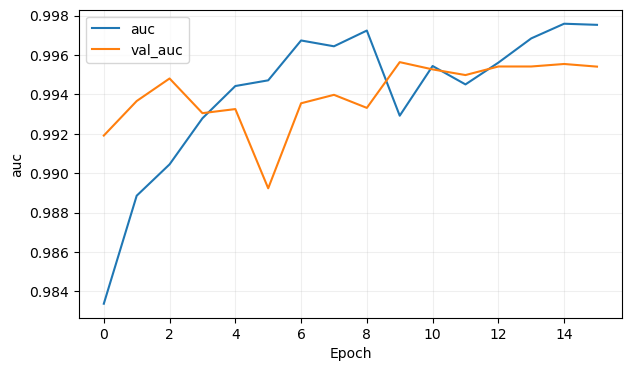

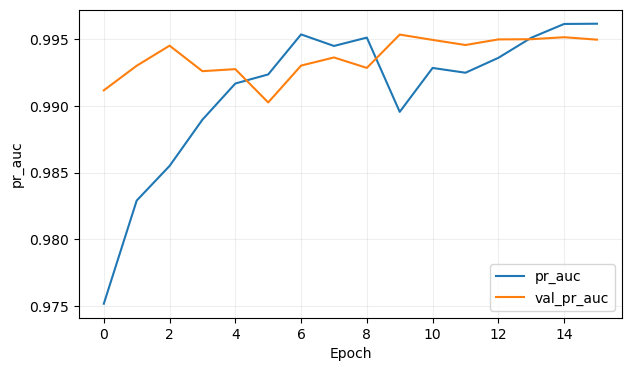

In [16]:
def plot_history(*histories):
    for key in ["loss","auc","pr_auc"]:
        tr=sum([h.history.get(key,[]) for h in histories],[])
        va=sum([h.history.get("val_"+key,[]) for h in histories],[])
        plt.figure(figsize=(7,4))
        plt.plot(tr,label=key)
        plt.plot(va,label="val_"+key)
        plt.xlabel("Epoch"); plt.ylabel(key); plt.legend(); plt.grid(alpha=.2)
        plt.show()

plot_history(history_head,history_fine)

## 9. Deep embeddings + early fusion + late fusion + stacking

In [17]:
embedding_model=keras.Model(dl_model.input,dl_model.get_layer("deep_embedding").output)

Xd_train=embedding_model.predict(make_ds(train_df),verbose=1)
Xd_val=embedding_model.predict(make_ds(val_df),verbose=1)
Xd_test=embedding_model.predict(make_ds(test_df),verbose=1)

Xe_train=np.hstack([Xh_train,Xd_train]).astype(np.float32)
Xe_val=np.hstack([Xh_val,Xd_val]).astype(np.float32)
Xe_test=np.hstack([Xh_test,Xd_test]).astype(np.float32)

early_model=Pipeline([
    ("scale",StandardScaler()),
    ("pca",PCA(n_components=.95,random_state=SEED)),
    ("svm",SVC(kernel="rbf",C=3,gamma="scale",
               class_weight="balanced",probability=True,random_state=SEED))
])
early_model.fit(Xe_train,y_train)

p_cv_train=svm_baseline.predict_proba(Xh_train)[:,1]
p_cv_val=svm_baseline.predict_proba(Xh_val)[:,1]
p_cv_test=svm_baseline.predict_proba(Xh_test)[:,1]

p_dl_train=dl_model.predict(make_ds(train_df),verbose=0).ravel()
p_dl_val=dl_model.predict(val_ds,verbose=0).ravel()
p_dl_test=dl_model.predict(test_ds,verbose=0).ravel()

p_early_val=early_model.predict_proba(Xe_val)[:,1]
p_early_test=early_model.predict_proba(Xe_test)[:,1]

weights=np.linspace(0,1,101)
scores=[roc_auc_score(y_val,w*p_dl_val+(1-w)*p_cv_val) for w in weights]
best_w=float(weights[np.argmax(scores)])
p_late_val=best_w*p_dl_val+(1-best_w)*p_cv_val
p_late_test=best_w*p_dl_test+(1-best_w)*p_cv_test
print("Best late-fusion DL weight:",best_w)

stacker=LogisticRegression(class_weight="balanced",random_state=SEED)
stacker.fit(np.c_[p_cv_train,p_dl_train],y_train)
p_stack_val=stacker.predict_proba(np.c_[p_cv_val,p_dl_val])[:,1]
p_stack_test=stacker.predict_proba(np.c_[p_cv_test,p_dl_test])[:,1]

38/38 [==============================] - 23s 590ms/step
Best late-fusion DL weight: 0.36


## 10. Validation-only threshold selection

In [18]:
def threshold_f1(y,p):
    ts=np.linspace(.01,.99,197)
    return float(ts[np.argmax([f1_score(y,p>=t) for t in ts])])

def threshold_youden(y,p):
    fpr,tpr,ts=roc_curve(y,p)
    return float(ts[np.argmax(tpr-fpr)])

def threshold_min_sensitivity(y,p,min_sens=.95):
    candidates=[]
    for t in np.linspace(.01,.99,197):
        pred=p>=t
        tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
        sens=tp/max(tp+fn,1); spec=tn/max(tn+fp,1)
        if sens>=min_sens:
            candidates.append((spec,t,sens))
    return float(max(candidates)[1]) if candidates else threshold_youden(y,p)

val_probs={
    "CV + SVM":p_cv_val,
    "Deep":p_dl_val,
    "Early fusion":p_early_val,
    "Late fusion":p_late_val,
    "Stacking":p_stack_val
}
for name,p in val_probs.items():
    print(name,round(roc_auc_score(y_val,p),4))

SELECTED_MODEL=max(val_probs,key=lambda k:roc_auc_score(y_val,val_probs[k]))
vp=val_probs[SELECTED_MODEL]
THRESHOLD_F1=threshold_f1(y_val,vp)
THRESHOLD_YOUDEN=threshold_youden(y_val,vp)
THRESHOLD_HIGH_SENS=threshold_min_sensitivity(y_val,vp,.95)

print("Selected:",SELECTED_MODEL)
print("F1:",THRESHOLD_F1,"Youden:",THRESHOLD_YOUDEN,
      "95%-sensitivity:",THRESHOLD_HIGH_SENS)

CV + SVM 0.9991
Deep 0.9956
Early fusion 0.9998
Late fusion 0.9995
Stacking 0.9995
Selected: Early fusion
F1: 0.51 Youden: 0.546062194481434 95%-sensitivity: 0.905


## 11. Untouched-test evaluation + bootstrap confidence intervals

In [19]:
def binary_metrics(y,p,threshold=.5):
    pred=(p>=threshold).astype(int)
    tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    return {
        "accuracy":accuracy_score(y,pred),
        "balanced_accuracy":balanced_accuracy_score(y,pred),
        "sensitivity":recall_score(y,pred,zero_division=0),
        "specificity":tn/max(tn+fp,1),
        "precision":precision_score(y,pred,zero_division=0),
        "NPV":tn/max(tn+fn,1),
        "F1":f1_score(y,pred,zero_division=0),
        "ROC_AUC":roc_auc_score(y,p),
        "PR_AUC":average_precision_score(y,p)
    }

test_probs={
    "CV + SVM":p_cv_test,
    "Deep":p_dl_test,
    "Early fusion":p_early_test,
    "Late fusion":p_late_test,
    "Stacking":p_stack_test
}

comparison=pd.DataFrame({k:binary_metrics(y_test,p) for k,p in test_probs.items()}).T
display(comparison.sort_values("ROC_AUC",ascending=False))

selected_test_probs=test_probs[SELECTED_MODEL]
FINAL_THRESHOLD=THRESHOLD_YOUDEN
display(pd.Series(binary_metrics(y_test,selected_test_probs,FINAL_THRESHOLD),
                  name="selected test model"))

,accuracy,balanced_accuracy,sensitivity,specificity,precision,NPV,F1,ROC_AUC,PR_AUC
Early fusion,0.959528,0.955531,0.990909,0.920152,0.939655,0.987755,0.964602,0.997200,0.997864
CV + SVM,0.951096,0.948727,0.969697,0.927757,0.943953,0.960630,0.956652,0.995898,0.996889
Stacking,0.956155,0.953658,0.975758,0.931559,0.947059,0.968379,0.961194,0.995080,0.996029
Late fusion,0.957841,0.955559,0.975758,0.935361,0.949853,0.968504,0.962631,0.994988,0.995951
Deep,0.940978,0.942338,0.930303,0.954373,0.962382,0.916058,0.946071,0.990252,0.991814


accuracy             0.961214
balanced_accuracy    0.957432
sensitivity          0.990909
specificity          0.923954
precision            0.942363
NPV                  0.987805
F1                   0.966027
ROC_AUC              0.997200
PR_AUC               0.997864
Name: selected test model, dtype: float64

In [20]:
def bootstrap_ci(y,p,metric_fn,n_boot=1000,seed=42):
    rng=np.random.default_rng(seed)
    vals=[]; n=len(y)
    for _ in range(n_boot):
        idx=rng.integers(0,n,n)
        yy,pp=y[idx],p[idx]
        if len(np.unique(yy))<2:
            continue
        vals.append(metric_fn(yy,pp))
    return np.percentile(vals,[2.5,50,97.5])

print("ROC-AUC 95% CI:",
      bootstrap_ci(y_test,selected_test_probs,roc_auc_score))
print("PR-AUC 95% CI:",
      bootstrap_ci(y_test,selected_test_probs,average_precision_score))

ROC-AUC 95% CI: [0.99491657 0.9973224  0.9988493 ]
PR-AUC 95% CI: [0.9960574  0.99795657 0.99908776]


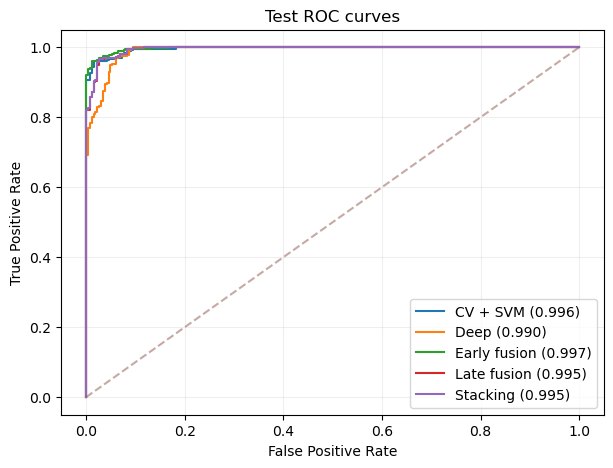

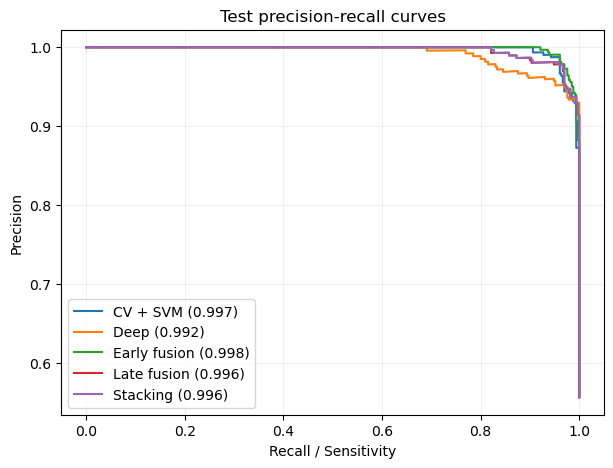

In [21]:
plt.figure(figsize=(7,5))
for name,p in test_probs.items():
    fpr,tpr,_=roc_curve(y_test,p)
    plt.plot(fpr,tpr,label=f"{name} ({roc_auc_score(y_test,p):.3f})")
plt.plot([0,1],[0,1],"--",alpha=.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Test ROC curves"); plt.legend(); plt.grid(alpha=.2); plt.show()

plt.figure(figsize=(7,5))
for name,p in test_probs.items():
    precision,recall,_=precision_recall_curve(y_test,p)
    plt.plot(recall,precision,label=f"{name} ({average_precision_score(y_test,p):.3f})")
plt.xlabel("Recall / Sensitivity"); plt.ylabel("Precision")
plt.title("Test precision-recall curves"); plt.legend(); plt.grid(alpha=.2); plt.show()

# Part II — Optional Tumor Segmentation

This section turns the project into a true detection + segmentation workflow when matching MRI/mask pairs exist.

In [22]:
def normalized_pair_key(path):
    s=Path(path).stem.lower()
    s=re.sub(r"_?mask(?:_consensus)?$","",s)
    s=re.sub(r"_?seg(?:mentation)?$","",s)
    s=re.sub(r"_?label$","",s)
    return s.strip("_- ")

def discover_segmentation_pairs(dataset_dir):
    files=[p for p in dataset_dir.rglob("*")
           if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS]
    masks=[p for p in files if is_mask_file(p)]
    images=[p for p in files if not is_mask_file(p)]
    image_map={}
    for p in images:
        image_map.setdefault(normalized_pair_key(p),[]).append(p)
    pairs=[]
    for m in masks:
        candidates=image_map.get(normalized_pair_key(m),[])
        if candidates:
            pairs.append({
                "image_path":str(candidates[0]),
                "mask_path":str(m),
                "group_id":infer_group_id(candidates[0])
            })
    return pd.DataFrame(pairs)

seg_df=discover_segmentation_pairs(DATASET_DIR)
print("Matched image/mask pairs:",len(seg_df))
display(seg_df.head())
SEGMENTATION_AVAILABLE=len(seg_df)>=20
print("Segmentation enabled:",SEGMENTATION_AVAILABLE)

Matched image/mask pairs: 9966


,image_path,mask_path,group_id
0,..\Datasets\Brain Tumor 12K Mri Images\Images_...,..\Datasets\Brain Tumor 12K Mri Images\Images_...,t1 - medulloblastoma - cerebellopontine angle ...
1,..\Datasets\Brain Tumor 12K Mri Images\Images_...,..\Datasets\Brain Tumor 12K Mri Images\Images_...,t1 - medulloblastoma - cerebellopontine angle ...
2,..\Datasets\Brain Tumor 12K Mri Images\Images_...,..\Datasets\Brain Tumor 12K Mri Images\Images_...,t1 - medulloblastoma - cerebellopontine angle ...
3,..\Datasets\Brain Tumor 12K Mri Images\Images_...,..\Datasets\Brain Tumor 12K Mri Images\Images_...,t1 - medulloblastoma - cerebellopontine angle ...
4,..\Datasets\Brain Tumor 12K Mri Images\Images_...,..\Datasets\Brain Tumor 12K Mri Images\Images_...,t1 - medulloblastoma - cerebellopontine angle ...


Segmentation enabled: True


## 12. Segmentation split and input pipeline

In [23]:
if SEGMENTATION_AVAILABLE:
    tmp=seg_df.copy()
    tmp["label"]=1
    seg_train,seg_val,seg_test=grouped_split(tmp,VAL_SIZE,TEST_SIZE,SEED)
    print(len(seg_train),len(seg_val),len(seg_test))
else:
    print("Not enough image/mask pairs. Fix pairing if masks are available.")

Using GROUPED splitting.
7180 1430 1356


In [24]:
def load_seg_pair_np(image_path,mask_path):
    img=preprocess_cv(image_path,SEG_SIZE)
    mask=read_image_safe(mask_path,True)
    mask=cv2.resize(mask,(SEG_SIZE,SEG_SIZE),interpolation=cv2.INTER_NEAREST)
    mask=(mask>0).astype(np.float32)
    return img[...,None].astype(np.float32),mask[...,None]

def tf_load_seg(image_path,mask_path):
    def _py(ip,mp):
        return load_seg_pair_np(ip.numpy().decode("utf-8"),mp.numpy().decode("utf-8"))
    x,y=tf.py_function(_py,[image_path,mask_path],[tf.float32,tf.float32])
    x.set_shape((SEG_SIZE,SEG_SIZE,1))
    y.set_shape((SEG_SIZE,SEG_SIZE,1))
    return x,y

def make_seg_ds(frame,training=False):
    ds=tf.data.Dataset.from_tensor_slices(
        (frame.image_path.astype(str).to_numpy(),
         frame.mask_path.astype(str).to_numpy())
    )
    if training:
        ds=ds.shuffle(len(frame),seed=SEED)
    return ds.map(tf_load_seg,num_parallel_calls=AUTOTUNE).batch(SEG_BATCH_SIZE).prefetch(AUTOTUNE)

if SEGMENTATION_AVAILABLE:
    seg_train_ds=make_seg_ds(seg_train,True)
    seg_val_ds=make_seg_ds(seg_val)
    seg_test_ds=make_seg_ds(seg_test)

## 13. 2D U-Net segmentation baseline

In [25]:
def conv_block(x,f):
    x=layers.Conv2D(f,3,padding="same",kernel_initializer="he_normal")(x)
    x=layers.BatchNormalization()(x); x=layers.Activation("relu")(x)
    x=layers.Conv2D(f,3,padding="same",kernel_initializer="he_normal")(x)
    x=layers.BatchNormalization()(x)
    return layers.Activation("relu")(x)

def build_unet(shape=(SEG_SIZE,SEG_SIZE,1),base=32):
    inp=keras.Input(shape)
    c1=conv_block(inp,base); p1=layers.MaxPool2D()(c1)
    c2=conv_block(p1,base*2); p2=layers.MaxPool2D()(c2)
    c3=conv_block(p2,base*4); p3=layers.MaxPool2D()(c3)
    c4=conv_block(p3,base*8); p4=layers.MaxPool2D()(c4)
    bn=conv_block(p4,base*16)
    u4=layers.Conv2DTranspose(base*8,2,2,padding="same")(bn); d4=conv_block(layers.Concatenate()([u4,c4]),base*8)
    u3=layers.Conv2DTranspose(base*4,2,2,padding="same")(d4); d3=conv_block(layers.Concatenate()([u3,c3]),base*4)
    u2=layers.Conv2DTranspose(base*2,2,2,padding="same")(d3); d2=conv_block(layers.Concatenate()([u2,c2]),base*2)
    u1=layers.Conv2DTranspose(base,2,2,padding="same")(d2); d1=conv_block(layers.Concatenate()([u1,c1]),base)
    out=layers.Conv2D(1,1,activation="sigmoid")(d1)
    return keras.Model(inp,out,name="BrainTumor_UNet")

def dice_coef(y_true,y_pred,smooth=1e-6):
    yt=tf.reshape(tf.cast(y_true,tf.float32),[-1])
    yp=tf.reshape(tf.cast(y_pred,tf.float32),[-1])
    inter=tf.reduce_sum(yt*yp)
    return (2*inter+smooth)/(tf.reduce_sum(yt)+tf.reduce_sum(yp)+smooth)

def dice_bce_loss(y_true,y_pred):
    bce=tf.reduce_mean(keras.losses.binary_crossentropy(y_true,y_pred))
    return bce+(1-dice_coef(y_true,y_pred))

if SEGMENTATION_AVAILABLE:
    unet=build_unet()
    unet.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=dice_bce_loss,
        metrics=[dice_coef,keras.metrics.BinaryIoU(target_class_ids=[1],threshold=.5)]
    )
    unet.summary()

Model: "BrainTumor_UNet"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 1)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256, 32)         320       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 256, 256, 32)         128       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 256, 256, 32)         0         ['batch_normaliz

In [29]:
# ============================================================
# ULTRA-FAST U-NET SEGMENTATION EXPERIMENT
# ============================================================

# Designed for quick experimentation on CPU / limited hardware.
# This is NOT intended to be the final publication-quality
# segmentation experiment.

ULTRA_SEG_SIZE = 96
ULTRA_BATCH_SIZE = 16

# Limit the number of cases used for this quick experiment.
MAX_SEG_TRAIN = 400
MAX_SEG_VAL = 100

# Only two epochs for pipeline validation.
ULTRA_EPOCHS = 2


# ============================================================
# 1. USE A SMALL SUBSET OF THE SEGMENTATION DATA
# ============================================================

if SEGMENTATION_AVAILABLE:

    seg_train_small = (
        seg_train
        .sample(
            n=min(MAX_SEG_TRAIN, len(seg_train)),
            random_state=SEED
        )
        .reset_index(drop=True)
    )

    seg_val_small = (
        seg_val
        .sample(
            n=min(MAX_SEG_VAL, len(seg_val)),
            random_state=SEED
        )
        .reset_index(drop=True)
    )

    print("Ultra-fast segmentation experiment")
    print("-----------------------------------")
    print("Training samples:", len(seg_train_small))
    print("Validation samples:", len(seg_val_small))
    print("Image size:", ULTRA_SEG_SIZE)
    print("Batch size:", ULTRA_BATCH_SIZE)
    print("Epochs:", ULTRA_EPOCHS)


# ============================================================
# 2. FAST IMAGE/MASK LOADER
# ============================================================

def load_seg_pair_ultra(image_path, mask_path):

    # Load MRI directly as grayscale.
    img = read_image_safe(
        image_path,
        grayscale=True
    )

    # Resize immediately to minimize preprocessing cost.
    img = cv2.resize(
        img,
        (ULTRA_SEG_SIZE, ULTRA_SEG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    img = img.astype(np.float32) / 255.0

    # Load mask.
    mask = read_image_safe(
        mask_path,
        grayscale=True
    )

    mask = cv2.resize(
        mask,
        (ULTRA_SEG_SIZE, ULTRA_SEG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    mask = (mask > 0).astype(np.float32)

    return (
        img[..., None],
        mask[..., None]
    )


def tf_load_seg_ultra(image_path, mask_path):

    def _loader(ip, mp):

        image_file = ip.numpy().decode("utf-8")
        mask_file = mp.numpy().decode("utf-8")

        return load_seg_pair_ultra(
            image_file,
            mask_file
        )

    image, mask = tf.py_function(
        _loader,
        [image_path, mask_path],
        [tf.float32, tf.float32]
    )

    image.set_shape(
        [ULTRA_SEG_SIZE, ULTRA_SEG_SIZE, 1]
    )

    mask.set_shape(
        [ULTRA_SEG_SIZE, ULTRA_SEG_SIZE, 1]
    )

    return image, mask


# ============================================================
# 3. CREATE SMALL DATASETS
# ============================================================

def make_seg_ds_ultra(frame, training=False):

    ds = tf.data.Dataset.from_tensor_slices(
        (
            frame["image_path"].astype(str).values,
            frame["mask_path"].astype(str).values
        )
    )

    if training:

        ds = ds.shuffle(
            buffer_size=len(frame),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        tf_load_seg_ultra,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(
        ULTRA_BATCH_SIZE
    )

    ds = ds.prefetch(
        tf.data.AUTOTUNE
    )

    return ds


if SEGMENTATION_AVAILABLE:

    seg_train_ds_ultra = make_seg_ds_ultra(
        seg_train_small,
        training=True
    )

    seg_val_ds_ultra = make_seg_ds_ultra(
        seg_val_small,
        training=False
    )


# ============================================================
# 4. TINY U-NET
# ============================================================

def tiny_conv_block(x, filters):

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    return x


def build_tiny_unet():

    inputs = keras.Input(
        shape=(ULTRA_SEG_SIZE, ULTRA_SEG_SIZE, 1)
    )

    # Encoder
    c1 = tiny_conv_block(inputs, 8)
    p1 = layers.MaxPooling2D()(c1)

    c2 = tiny_conv_block(p1, 16)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = tiny_conv_block(p2, 32)

    # Decoder
    u2 = layers.UpSampling2D()(b)
    u2 = layers.Concatenate()([u2, c2])
    c3 = tiny_conv_block(u2, 16)

    u1 = layers.UpSampling2D()(c3)
    u1 = layers.Concatenate()([u1, c1])
    c4 = tiny_conv_block(u1, 8)

    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid"
    )(c4)

    return keras.Model(
        inputs,
        outputs,
        name="Tiny_UNet"
    )


# ============================================================
# 5. DICE METRIC
# ============================================================

def dice_coef(y_true, y_pred, smooth=1e-6):

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(
        y_true * y_pred
    )

    return (
        (2.0 * intersection + smooth) /
        (
            tf.reduce_sum(y_true)
            + tf.reduce_sum(y_pred)
            + smooth
        )
    )


# ============================================================
# 6. BUILD AND COMPILE
# ============================================================

if SEGMENTATION_AVAILABLE:

    unet = build_tiny_unet()

    unet.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="binary_crossentropy",
        metrics=[dice_coef]
    )

    print()
    print("Tiny U-Net created.")
    print("Parameters:", unet.count_params())


# ============================================================
# 7. CHECKPOINT
# ============================================================

if SEGMENTATION_AVAILABLE:

    ultra_checkpoint = str(
        MODEL_DIR / "tiny_unet_weights.h5"
    )

    ultra_callbacks = [

        keras.callbacks.ModelCheckpoint(
            filepath=ultra_checkpoint,
            monitor="val_dice_coef",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        )
    ]


# ============================================================
# 8. TRAIN FOR ONLY TWO EPOCHS
# ============================================================

if SEGMENTATION_AVAILABLE:

    print()
    print("Starting ultra-fast U-Net training...")
    print()

    seg_history = unet.fit(
        seg_train_ds_ultra,
        validation_data=seg_val_ds_ultra,
        epochs=ULTRA_EPOCHS,
        callbacks=ultra_callbacks,
        verbose=1
    )

    unet.load_weights(
        ultra_checkpoint
    )

    print()
    print("Ultra-fast segmentation training complete.")

Ultra-fast segmentation experiment
-----------------------------------
Training samples: 400
Validation samples: 100
Image size: 96
Batch size: 16
Epochs: 2

Tiny U-Net created.
Parameters: 29617

Starting ultra-fast U-Net training...

Epoch 1/2
25/25 [==============================] - ETA: 0s - loss: 0.4030 - dice_coef: 0.0187
Epoch 1: val_dice_coef improved from -inf to 0.01622, saving model to models_v2\tiny_unet_weights.h5
25/25 [==============================] - 5s 137ms/step - loss: 0.4030 - dice_coef: 0.0187 - val_loss: 0.1778 - val_dice_coef: 0.0162
Epoch 2/2
25/25 [==============================] - ETA: 0s - loss: 0.1008 - dice_coef: 0.0468
Epoch 2: val_dice_coef improved from 0.01622 to 0.08057, saving model to models_v2\tiny_unet_weights.h5
25/25 [==============================] - 3s 134ms/step - loss: 0.1008 - dice_coef: 0.0468 - val_loss: 0.1102 - val_dice_coef: 0.0806

Ultra-fast segmentation training complete.


## 14. Segmentation evaluation and visualization

In [31]:
# ============================================================
# TINY U-NET SEGMENTATION TEST DATASET + METRICS
# ============================================================

# ------------------------------------------------------------
# 1. Create a 96x96 test dataset
# ------------------------------------------------------------

if SEGMENTATION_AVAILABLE:

    # Optional:
    # Limit the test set for faster evaluation.
    # Increase this later if you want a full evaluation.
    MAX_SEG_TEST = 100

    seg_test_small = (
        seg_test
        .sample(
            n=min(MAX_SEG_TEST, len(seg_test)),
            random_state=SEED
        )
        .reset_index(drop=True)
    )

    # IMPORTANT:
    # This uses make_seg_ds_ultra(), which produces
    # 96x96 images matching the Tiny U-Net input size.
    seg_test_ds_ultra = make_seg_ds_ultra(
        seg_test_small,
        training=False
    )

    print("Tiny U-Net test dataset created.")
    print("Test samples:", len(seg_test_small))
    print(
        "Expected model input:",
        unet.input_shape
    )


# ============================================================
# 2. SEGMENTATION METRICS
# ============================================================

def segmentation_metrics(
    model,
    ds,
    threshold=0.5
):

    dices = []
    ious = []
    sensitivities = []
    specificities = []

    for xb, yb in ds:

        # Faster than model.predict() inside the loop.
        pb = model(
            xb,
            training=False
        ).numpy()

        yb = yb.numpy()

        for y_true, y_prob in zip(yb, pb):

            # Flatten ground truth
            yt = (
                y_true
                .ravel()
                .astype(np.int32)
            )

            # Convert probabilities to binary prediction
            yp = (
                y_prob.ravel() >= threshold
            ).astype(np.int32)


            # ------------------------------------------------
            # Dice coefficient
            # ------------------------------------------------

            intersection = np.sum(
                yt * yp
            )

            dice = (
                2.0 * intersection + 1e-6
            ) / (
                np.sum(yt)
                + np.sum(yp)
                + 1e-6
            )

            dices.append(dice)


            # ------------------------------------------------
            # Intersection over Union
            # ------------------------------------------------

            union = np.sum(
                (yt + yp) > 0
            )

            iou = (
                intersection + 1e-6
            ) / (
                union + 1e-6
            )

            ious.append(iou)


            # ------------------------------------------------
            # Confusion matrix
            # ------------------------------------------------

            tn, fp, fn, tp = confusion_matrix(
                yt,
                yp,
                labels=[0, 1]
            ).ravel()


            # Sensitivity / Recall
            sensitivity = (
                tp / max(tp + fn, 1)
            )

            sensitivities.append(
                sensitivity
            )


            # Specificity
            specificity = (
                tn / max(tn + fp, 1)
            )

            specificities.append(
                specificity
            )


    # --------------------------------------------------------
    # Final results
    # --------------------------------------------------------

    results = pd.Series({

        "Dice":
            np.mean(dices),

        "IoU":
            np.mean(ious),

        "Sensitivity":
            np.mean(sensitivities),

        "Specificity":
            np.mean(specificities),

        "N_test_images":
            len(dices)

    })

    return results


# ============================================================
# 3. EVALUATE TINY U-NET
# ============================================================

if SEGMENTATION_AVAILABLE:

    print()
    print(
        "Evaluating Tiny U-Net segmentation..."
    )

    seg_results = segmentation_metrics(
        unet,
        seg_test_ds_ultra,
        threshold=0.5
    )

    print()
    print("Tiny U-Net Test Results")
    print("-----------------------")

    display(
        seg_results.to_frame(
            name="Value"
        )
    )

Tiny U-Net test dataset created.
Test samples: 100
Expected model input: (None, 96, 96, 1)

Evaluating Tiny U-Net segmentation...

Tiny U-Net Test Results
-----------------------


,Value
Dice,0.11
IoU,0.11
Sensitivity,0.00
Specificity,1.00
N_test_images,100.00


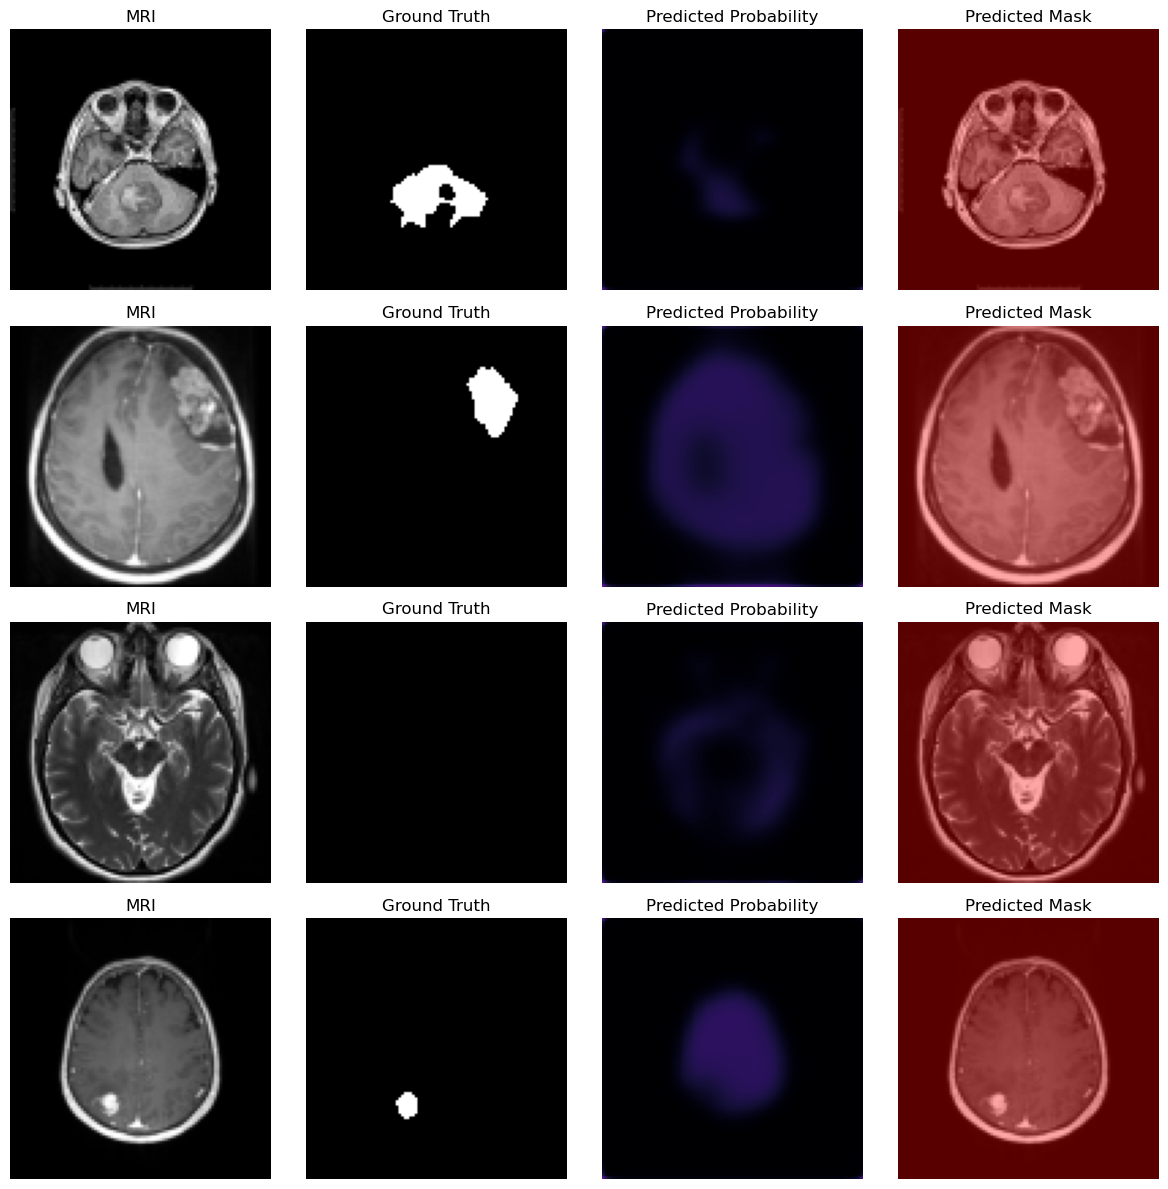

In [33]:
# ============================================================
# VISUALIZE TINY U-NET SEGMENTATION RESULTS
# ============================================================

if SEGMENTATION_AVAILABLE:

    # IMPORTANT:
    # Use the 96x96 test dataset created for the Tiny U-Net,
    # NOT the original 256x256 seg_test_ds.
    xb, yb = next(iter(seg_test_ds_ultra))

    # Run inference directly.
    # This is slightly simpler/faster than model.predict()
    # for a single batch.
    pb = unet(
        xb,
        training=False
    ).numpy()

    # Show up to 4 examples.
    n = min(4, xb.shape[0])

    fig, axes = plt.subplots(
        n,
        4,
        figsize=(12, 3 * n),
        squeeze=False
    )

    for i in range(n):

        # ----------------------------------------------------
        # MRI
        # ----------------------------------------------------
        axes[i, 0].imshow(
            xb[i, ..., 0].numpy(),
            cmap="gray"
        )

        axes[i, 0].set_title("MRI")


        # ----------------------------------------------------
        # Ground-truth segmentation
        # ----------------------------------------------------
        axes[i, 1].imshow(
            yb[i, ..., 0].numpy(),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        axes[i, 1].set_title("Ground Truth")


        # ----------------------------------------------------
        # Predicted probability map
        # ----------------------------------------------------
        axes[i, 2].imshow(
            pb[i, ..., 0],
            cmap="magma",
            vmin=0,
            vmax=1
        )

        axes[i, 2].set_title(
            "Predicted Probability"
        )


        # ----------------------------------------------------
        # Prediction overlay
        # ----------------------------------------------------
        axes[i, 3].imshow(
            xb[i, ..., 0].numpy(),
            cmap="gray"
        )

        predicted_mask = (
            pb[i, ..., 0] >= 0.5
        )

        axes[i, 3].imshow(
            predicted_mask,
            alpha=0.35,
            cmap="autumn"
        )

        axes[i, 3].set_title(
            "Predicted Mask"
        )


        # ----------------------------------------------------
        # Remove axes
        # ----------------------------------------------------
        for j in range(4):
            axes[i, j].axis("off")


    plt.tight_layout()
    plt.show()

else:

    print(
        "Segmentation is not available; "
        "visualization skipped."
    )

## 15. Classification error analysis

Inspect true positives, true negatives, false positives, and false negatives instead of looking only at aggregate metrics.

In [34]:
def confusion_groups(frame,probs,threshold):
    z=frame.copy().reset_index(drop=True)
    z["prob"]=probs
    z["pred"]=(z.prob>=threshold).astype(int)
    z["case"]=np.select([
        (z.label==1)&(z.pred==1),
        (z.label==0)&(z.pred==0),
        (z.label==0)&(z.pred==1),
        (z.label==1)&(z.pred==0)
    ],["TP","TN","FP","FN"],default="?")
    return z

errors=confusion_groups(test_df,selected_test_probs,FINAL_THRESHOLD)
display(errors.groupby("case").size())
display(errors[errors.case.isin(["FP","FN"])][["path","label","prob","pred","case"]].head(30))

case
FN      3
FP     20
TN    243
TP    327
dtype: int64

,path,label,prob,pred,case
88,..\Datasets\Brain Tumor 12K Mri Images\Images_...,0,0.930619,1,FP
89,..\Datasets\Brain Tumor 12K Mri Images\Images_...,0,0.705926,1,FP
90,..\Datasets\Brain Tumor 12K Mri Images\Images_...,0,0.994960,1,FP
91,..\Datasets\Brain Tumor 12K Mri Images\Images_...,0,0.992922,1,FP
92,..\Datasets\Brain Tumor 12K Mri Images\Images_...,0,0.882324,1,FP
93,..\Datasets\Brain Tumor 12K Mri Images\Images_...,0,0.842949,1,FP
94,..\Datasets\Brain Tumor 12K Mri Images\Images_...,0,0.739881,1,FP
96,..\Datasets\Brain Tumor 12K Mri Images\Images_...,0,0.756965,1,FP
97,..\Datasets\Brain Tumor 12K Mri Images\Images_...,0,0.908643,1,FP
98,..\Datasets\Brain Tumor 12K Mri Images\Images_...,0,0.971035,1,FP


## 16. Save trained models and metadata

In [35]:
dl_model.save(MODEL_DIR/"brain_tumor_classifier_v2.keras")
joblib.dump(svm_baseline,MODEL_DIR/"handcrafted_svm_v2.joblib")
joblib.dump(early_model,MODEL_DIR/"early_fusion_svm_v2.joblib")
joblib.dump(stacker,MODEL_DIR/"stacking_meta_classifier_v2.joblib")

if SEGMENTATION_AVAILABLE:
    unet.save(MODEL_DIR/"brain_tumor_unet_v2.keras")

metadata={
    "negative_class":NEGATIVE_CLASS,
    "positive_class":POSITIVE_CLASS,
    "img_size":IMG_SIZE,
    "seg_size":SEG_SIZE,
    "selected_model":SELECTED_MODEL,
    "late_fusion_dl_weight":best_w,
    "final_threshold":float(FINAL_THRESHOLD),
    "threshold_f1":float(THRESHOLD_F1),
    "threshold_youden":float(THRESHOLD_YOUDEN),
    "threshold_high_sensitivity":float(THRESHOLD_HIGH_SENS),
    "seed":SEED,
    "segmentation_available":bool(SEGMENTATION_AVAILABLE)
}
with open(MODEL_DIR/"metadata_v2.json","w") as f:
    json.dump(metadata,f,indent=2)
print("Saved to:",MODEL_DIR.resolve())

Saved to: C:\Users\fgmam\Documents\GitHub\Medical-Imaging-Research\Code\models_v2


## 17. Single-MRI inference

In [36]:
def predict_single_mri(path,return_segmentation=True):
    path=str(path)
    h=handcrafted_features(path)[None,:]
    p_cv=float(svm_baseline.predict_proba(h)[0,1])

    x=preprocess_dl_numpy(path)[None,...]
    p_dl=float(dl_model.predict(x,verbose=0).ravel()[0])
    emb=embedding_model.predict(x,verbose=0)

    p_early=float(early_model.predict_proba(np.hstack([h,emb]).astype(np.float32))[0,1])
    p_late=float(best_w*p_dl+(1-best_w)*p_cv)
    p_stack=float(stacker.predict_proba([[p_cv,p_dl]])[0,1])

    probs={"CV + SVM":p_cv,"Deep":p_dl,"Early fusion":p_early,
           "Late fusion":p_late,"Stacking":p_stack}
    final_prob=probs[SELECTED_MODEL]

    result={
        "selected_model":SELECTED_MODEL,
        "probability_tumor":final_prob,
        "threshold":FINAL_THRESHOLD,
        "prediction":POSITIVE_CLASS if final_prob>=FINAL_THRESHOLD else NEGATIVE_CLASS,
        "component_probabilities":probs
    }

    if return_segmentation and SEGMENTATION_AVAILABLE:
        sx=preprocess_cv(path,SEG_SIZE)[None,...,None]
        sm=unet.predict(sx,verbose=0)[0,...,0]
        result["segmentation_probability_map"]=sm
        result["segmentation_mask"]=(sm>=.5).astype(np.uint8)
    return result

# Research-quality next steps

For a stronger medical-imaging study:

- Replace heuristic group IDs with official **patient identifiers**.
- Keep a truly external institution/scanner cohort untouched until the end.
- Bootstrap confidence intervals at the **patient level**.
- Add calibration (Brier score, reliability curves, ECE).
- Add statistical model comparisons.
- If volumetric MRI is available, move from independent 2D slices to **3D U-Net / 3D CNN / nnU-Net-style** modeling.
- For multimodal glioma MRI, support T1, T1ce, T2 and FLAIR as distinct channels.
- Derive segmentation-assisted radiomic features from the predicted tumor ROI.
- Analyze domain shift, tumor subtype, scanner effects, and difficult failure cases.

**Most important rule:** never allow slices or derived images from the same patient to cross training, validation, and test partitions.